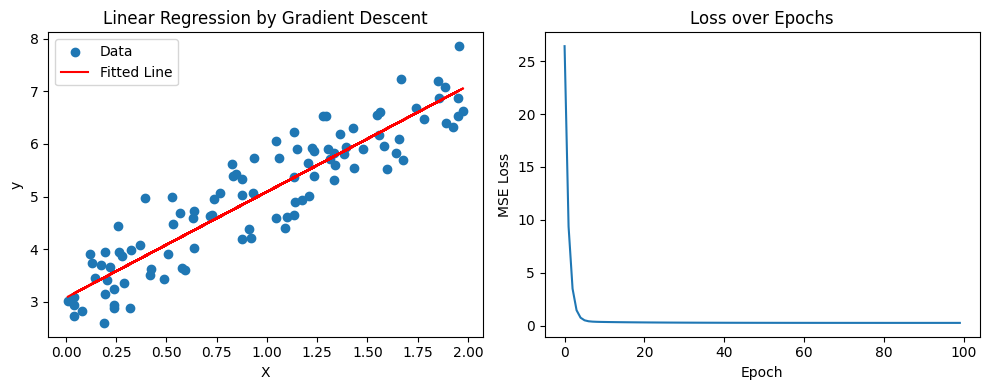

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성 (y = 2x + 3 + noise)
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 2 * X + 3 + np.random.randn(100, 1) * 0.5  # noise 추가

# 2. 경사하강법으로 선형회귀 구현
# 초기 파라미터 설정
theta_0 = 0.0  # 절편 (bias)
theta_1 = 0.0  # 기울기 (weight)

# 학습률과 반복 수
alpha = 0.1
epochs = 100

# 저장용 리스트
theta_0_list = []
theta_1_list = []
loss_list = []

# 경사하강법 반복
n = len(X)
for i in range(epochs):
    y_pred = theta_1 * X + theta_0
    error = y_pred - y
    loss = (1/n) * np.sum(error**2)

    grad_0 = (2/n) * np.sum(error)
    grad_1 = (2/n) * np.sum(error * X)

    theta_0 -= alpha * grad_0
    theta_1 -= alpha * grad_1

    theta_0_list.append(theta_0)
    theta_1_list.append(theta_1)
    loss_list.append(loss)

# 최종 파라미터로 예측
y_final_pred = theta_1 * X + theta_0

# 시각화
plt.figure(figsize=(10, 4))

# 산점도 + 회귀선
plt.subplot(1, 2, 1)
plt.scatter(X, y, label='Data')
plt.plot(X, y_final_pred, color='red', label='Fitted Line')
plt.title('Linear Regression by Gradient Descent')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# 손실값 그래프
plt.subplot(1, 2, 2)
plt.plot(loss_list)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml

# 1. 데이터 로딩
boston = fetch_openml(name='boston', version=1, as_frame=True)
X = boston.data
y = boston.target

#print(X.info())

# categorical 변수 --&gt; 수치형으로 변경
X['CHAS'] = X['CHAS'].astype(int)
X['RAD'] = X['RAD'].astype(int)

# 2. 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 4.예측 및 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("모델 평가")
print(f"▶ MSE: {mse:.2f}")
print(f"▶ RMSE: {rmse:.2f}")
print(f"▶ R² Score: {r2:.2f}")

# 5. 회귀 계수 출력 및 해석
coefficients = pd.Series(model.coef_, index=X.columns)

print("회귀 계수:")

print(coefficients.sort_values(ascending=False))

print("\n주요 변수 해석:")
print(f"NOX (일산화질소 농도): {coefficients['NOX']:.3f} → 일산화질소 농도 높을수록 집값 하락")
print(f"RM (방 개수): {coefficients['RM']:.3f} → 방이 많을수록 집값 상승")
print(f"CHAS (찰스강 인접 여부): {coefficients['CHAS']:.3f} → 찰스강 인접할수록 집값 상승")

모델 평가
▶ MSE: 24.29
▶ RMSE: 4.93
▶ R² Score: 0.67
회귀 계수:
RM          4.438835
CHAS        2.784438
RAD         0.262430
INDUS       0.040381
ZN          0.030110
B           0.012351
AGE        -0.006296
TAX        -0.010647
CRIM       -0.113056
LSTAT      -0.508571
PTRATIO    -0.915456
DIS        -1.447865
NOX       -17.202633
dtype: float64

주요 변수 해석:
NOX (일산화질소 농도): -17.203 → 일산화질소 농도 높을수록 집값 하락
RM (방 개수): 4.439 → 방이 많을수록 집값 상승
CHAS (찰스강 인접 여부): 2.784 → 찰스강 인접할수록 집값 상승


/tmp/ipykernel_1714397/1741820467.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['CHAS'] = X['CHAS'].astype(int)
/tmp/ipykernel_1714397/1741820467.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['RAD'] = X['RAD'].astype(int)


In [4]:
X_train.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.609125,11.569307,10.985050,0.071782,0.556484,6.315891,68.556436,3.808195,9.356436,404.032178,18.318317,356.278342,12.457351
std,8.875058,23.152481,6.894618,0.258447,0.117704,0.709452,27.994922,2.131226,8.589721,166.172655,2.228701,91.566533,7.110381
min,0.009060,0.000000,0.740000,0.000000,0.385000,3.863000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,0.081437,0.000000,5.130000,0.000000,0.452000,5.890500,45.550000,2.087875,4.000000,279.000000,16.800000,375.472500,6.772500
50%,0.261390,0.000000,8.560000,0.000000,0.538000,6.210000,77.700000,3.175750,5.000000,330.000000,18.700000,391.305000,10.925000
75%,3.202962,20.000000,18.100000,0.000000,0.631000,6.636750,93.650000,5.400800,12.000000,666.000000,20.200000,395.755000,16.372500
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


=== 성능 비교 ===
Linear (Raw)              | MSE: 24.2911 | R²: 0.6688
Linear (Standardized)     | MSE: 24.2911 | R²: 0.6688
Ridge (Raw)               | MSE: 24.4772 | R²: 0.6662
Ridge (Standardized)      | MSE: 24.3129 | R²: 0.6685
Lasso (Raw)               | MSE: 25.1556 | R²: 0.6570
Lasso (Standardized)      | MSE: 25.6567 | R²: 0.6501


/tmp/ipykernel_1714397/1440853358.py:56: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1714397/1440853358.py:56: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1714397/1440853358.py:56: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1714397/1440853358.py:56: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1714397/1440853358.py:56: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1714397/1440853358.py:56: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jh.sim/miniconda3/envs/ai_lecture/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

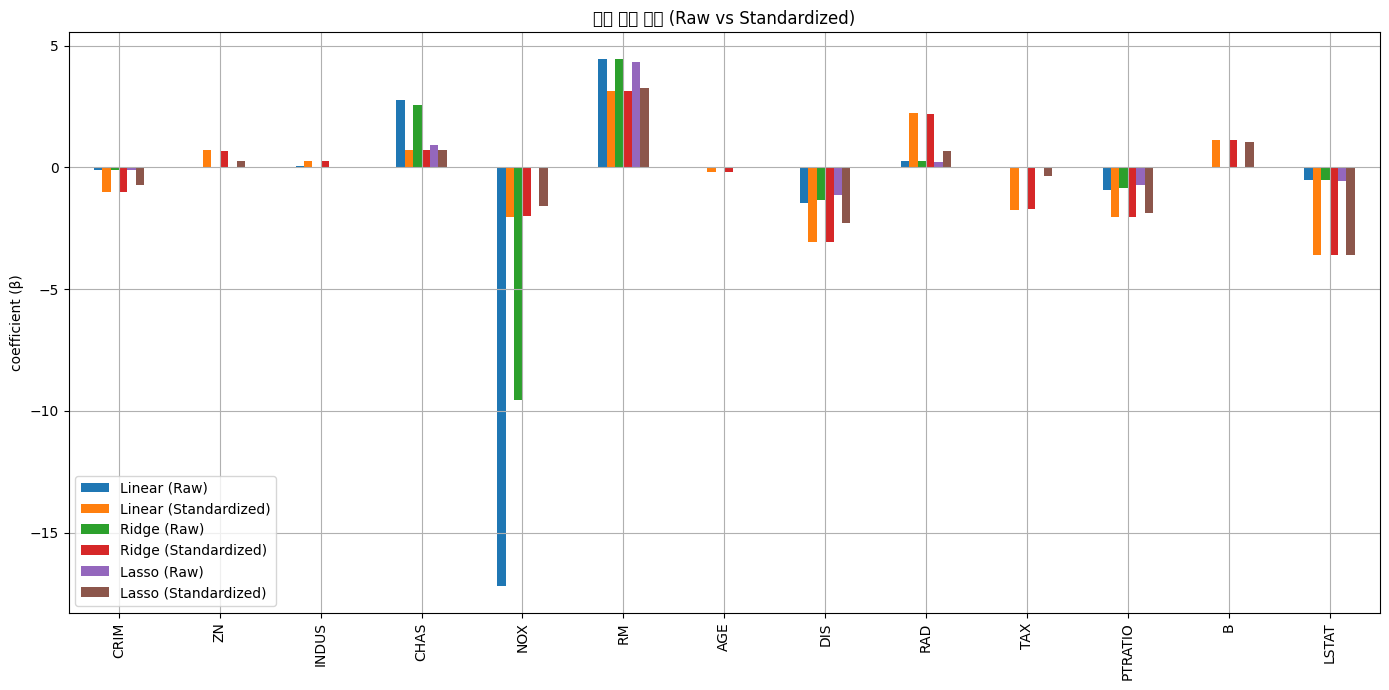

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

# 3. 표준화
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# 4. 회귀 모델 리스트 정의
models = {
    "Linear (Raw)": LinearRegression(),
    "Linear (Standardized)": LinearRegression(),
    "Ridge (Raw)": Ridge(alpha=1.0),
    "Ridge (Standardized)": Ridge(alpha=1.0),
    "Lasso (Raw)": Lasso(alpha=0.1),
    "Lasso (Standardized)": Lasso(alpha=0.1)
}

# 5. 모델 학습 및 평가
results = []

for name, model in models.items():
    if "Standardized" in name:
        model.fit(X_train_std, y_train)
        y_pred = model.predict(X_test_std)
        coef = model.coef_
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        coef = model.coef_

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'Model': name,
        'MSE': mse,
        'R2': r2,
        'Coefficients': coef
    })

# 6. 결과 출력
print("=== 성능 비교 ===")
for r in results:
    print(f"{r['Model']:25} | MSE: {r['MSE']:.4f} | R²: {r['R2']:.4f}")

# 7. 회귀 계수 시각화 (Linear, Ridge, Lasso 모두 비교)
coef_df = pd.DataFrame({
    r['Model']: r['Coefficients'] for r in results
}, index=boston.feature_names)


coef_df.plot(kind='bar', figsize=(14, 7), title='회귀 계수 비교 (Raw vs Standardized)')
plt.ylabel("coefficient (β)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
coef_df

,Linear (Raw),Linear (Standardized),Ridge (Raw),Ridge (Standardized),Lasso (Raw),Lasso (Standardized)
CRIM,-0.113056,-1.002135,-0.109234,-0.992187,-0.104157,-0.718365
ZN,0.030110,0.696269,0.032271,0.677749,0.034893,0.259627
INDUS,0.040381,0.278065,0.007498,0.252214,-0.016785,-0.000000
CHAS,2.784438,0.718738,2.545470,0.722481,0.919952,0.698221
NOX,-17.202633,-2.022319,-9.537952,-1.990835,-0.000000,-1.568142
RM,4.438835,3.145240,4.464505,3.151572,4.311687,3.271507
AGE,-0.006296,-0.176048,-0.012191,-0.177262,-0.015126,-0.000000
DIS,-1.447865,-3.081908,-1.338700,-3.045029,-1.151487,-2.284449
RAD,0.262430,2.251407,0.248882,2.173249,0.239237,0.671938
TAX,-0.010647,-1.767014,-0.011475,-1.695559,-0.012962,-0.356654


In [ ]:
from sympy import symbols, Derivative

n, x, W, b, y = symbols('n, x, W, b, y')
fx = (y - W*x -b)**2

Derivative(fx, W).doit()
Derivative(fx, b).doit()

del W, b, y, x, n


W, b, y


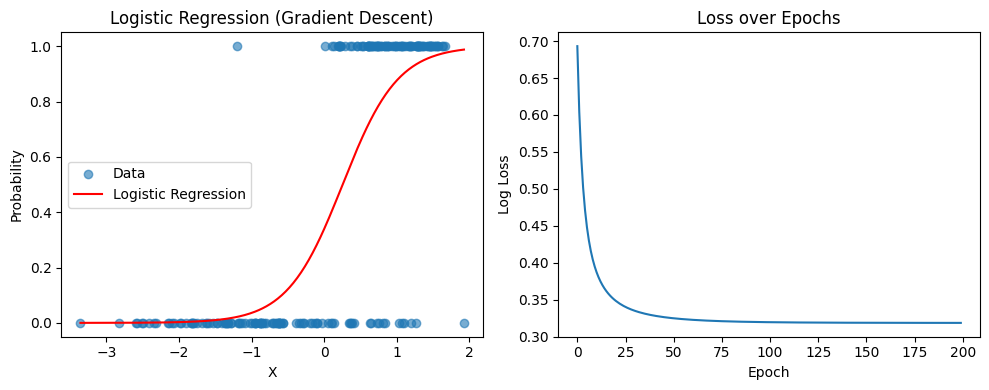

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. 데이터 생성 (2D 이진 분류 문제)
X, y = make_classification(n_samples=200, n_features=1, n_informative=1, 
                           n_redundant=0, n_clusters_per_class=1, flip_y=0.05, random_state=0)

# 2. 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 3. 로지스틱 손실 함수
def compute_loss(y_true, y_pred):
    epsilon = 1e-15  # 로그 안정성
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 4. 경사하강법 구현
def logistic_regression_gd(X, y, lr=0.1, epochs=100):
    n = X.shape[0]
    X_b = np.c_[np.ones((n, 1)), X]  # 절편항 포함
    theta = np.zeros(X_b.shape[1])  # 초기 파라미터 [theta_0, theta_1]

    loss_history = []

    for epoch in range(epochs):
        z = X_b @ theta
        y_pred = sigmoid(z)
        error = y_pred - y
        grad = X_b.T @ error / n
        theta -= lr * grad
        loss = compute_loss(y, y_pred)
        loss_history.append(loss)

    return theta, loss_history

# 5. 모델 학습
theta, loss_history = logistic_regression_gd(X, y, lr=0.5, epochs=200)

# 6. 예측 및 시각화
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_plot_b = np.c_[np.ones((X_plot.shape[0], 1)), X_plot]
y_plot = sigmoid(X_plot_b @ theta)

plt.figure(figsize=(10, 4))

# 예측 결과 시각화
plt.subplot(1, 2, 1)
plt.scatter(X, y, label='Data', alpha=0.6)
plt.plot(X_plot, y_plot, color='red', label='Logistic Regression')
plt.title('Logistic Regression (Gradient Descent)')
plt.xlabel('X')
plt.ylabel('Probability')
plt.legend()

# 손실 함수 시각화
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')

plt.tight_layout()
plt.show()

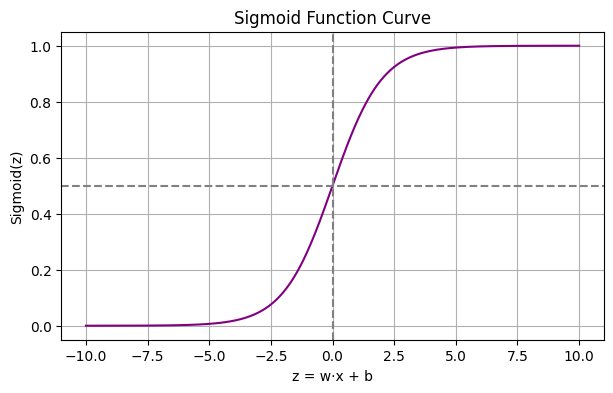

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D  # 3D 시각화용

# ---------------------------------------------------
# 1D 시그모이드 함수 곡선 시각화  
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_vals = np.linspace(-10, 10, 500)
p_vals = sigmoid(z_vals)


plt.figure(figsize=(7, 4))
plt.plot(z_vals, p_vals, color='purple')
plt.axhline(0.5, linestyle='--', color='gray')
plt.axvline(0, linestyle='--', color='gray')
plt.title("Sigmoid Function Curve")
plt.xlabel("z = w·x + b")
plt.ylabel("Sigmoid(z)")
plt.grid(True)
plt.show()

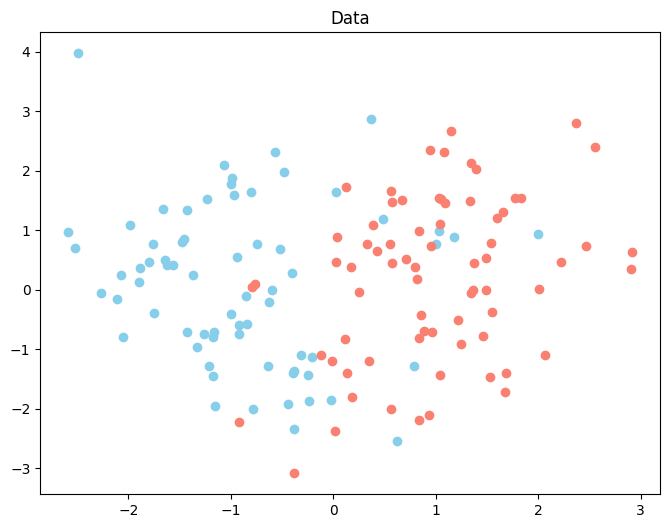

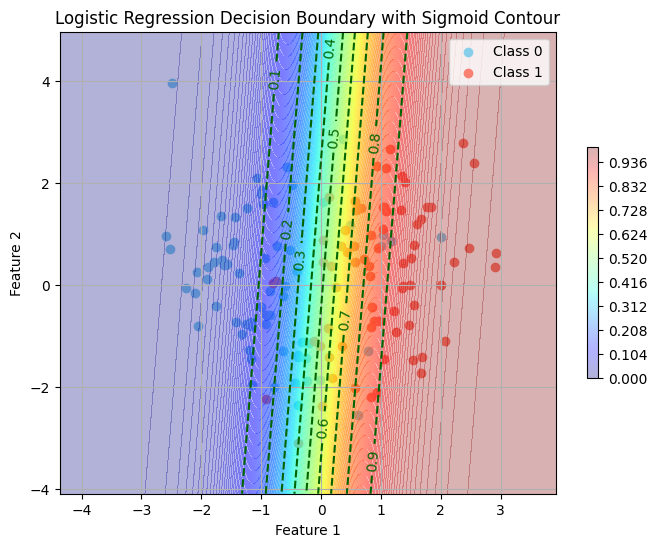

In [3]:
# ---------------------------------------------------
# 1. 데이터 생성 및 학습
X, y = make_classification(n_samples=200, n_features=2,
                           n_informative=2, n_redundant=0,
                           random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(8, 6))
plt.title("Data")
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],
            color='skyblue', label='Class 0')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1],
            color='salmon', label='Class 1')
plt.show()


model = LogisticRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------
# 2D 시각화: 데이터 산점도 + 결정 경계선 + 시그모이드 등고선
fig = plt.figure(figsize=(8, 6))
fig.set_facecolor('white')
ax = fig.add_subplot()
# 산점도
ax.set_title("Logistic Regression Decision Boundary with Sigmoid Contour")
ax.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],
            color='skyblue', label='Class 0')
ax.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1],
            color='salmon', label='Class 1')

# 시그모이드 확률 등고선
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)
contour = ax.contour(xx, yy, probs, levels= 10, linewidths=1.5,
                      colors='darkgreen', linestyles='dashed')
contour2 = ax.contourf(xx, yy, probs, levels=256, cmap='jet', alpha=0.3)
ax.clabel(contour, contour.levels, inline=True)
fig.colorbar(contour2, shrink=0.5)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.grid(True)
plt.show()

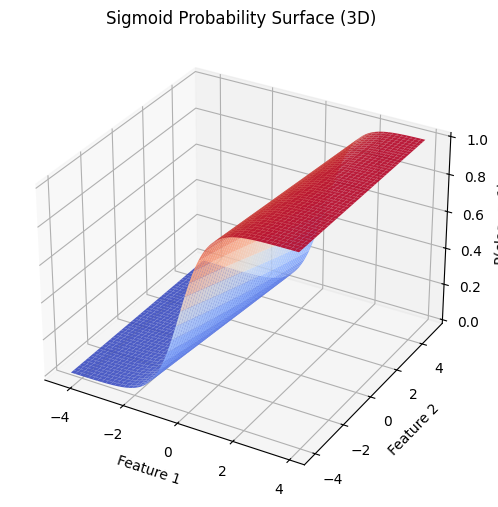

In [6]:
# ---------------------------------------------------
# 3D 시각화: 확률 곡면
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111, projection='3d')
# Z축: 확률
ax.plot_surface(xx, yy, probs, cmap='coolwarm', edgecolor='none', alpha=0.9)
ax.set_title("Sigmoid Probability Surface (3D)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("P(class = 1)")
plt.show()